<a href="https://colab.research.google.com/github/hsb0205/AI-CLASS/blob/main/WEEK05/diabetes_DL_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
/content/drive/MyDrive/Colab Notebooks/WEEK02/diabetes.csv

In [ ]:
# diabetes.csv 파일을 바탕으로 딥러닝(Deep Learning) regression 실습

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

path = '/content/drive/MyDrive/Colab Notebooks/WEEK02/diabetes.csv'

# CSV 파일을 DataFrame 형태로 읽기
df = pd.read_csv(path)
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [ ]:
# 데이터 전체 확인
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [ ]:
# 컬럼명 확인
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

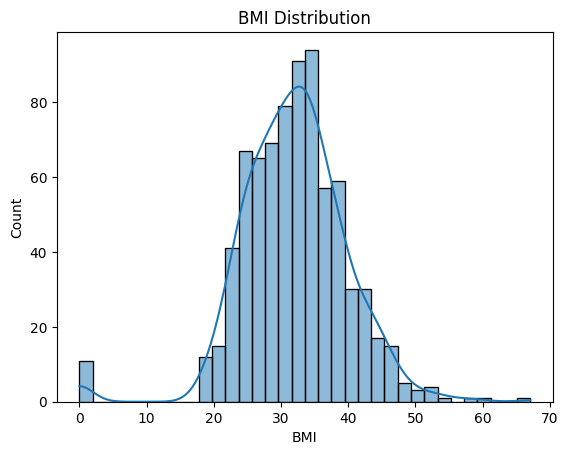

In [ ]:
# 정답 데이터(BMI) 분포 확인
sns.histplot(df['BMI'], kde=True)
plt.xlabel("BMI")
plt.ylabel("Count")
plt.title("BMI Distribution")
plt.show()

In [ ]:
# 결측치 확인
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
# 결측치 제거
df = df.dropna()
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
# 정답 데이터(y) 설정
# BMI는 연속형 수치값이므로 회귀(regression)의 목표값으로 사용한다.
y = df['BMI']
print(y.head())

0    33.6
1    26.6
2    23.3
3    28.1
4    43.1
Name: BMI, dtype: float64


In [ ]:
# 입력 데이터(X) 생성
# BMI는 정답 값이므로 입력 데이터에서 제거
# Outcome 열도 분류용 레이블 성격이므로 입력 변수에서 제거
X = df.drop(['BMI', 'Outcome'], axis=1)
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,0.627,50
1,1,85,66,29,0,0.351,31
2,8,183,64,0,0,0.672,32
3,1,89,66,23,94,0.167,21
4,0,137,40,35,168,2.288,33


In [ ]:
# 입력 데이터와 정답 데이터의 크기 확인
# X는 (데이터 개수, feature 개수), y는 (데이터 개수,) 형태가 된다.
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (768, 7)
y shape: (768,)


In [ ]:
# 딥러닝 입력을 위해 DataFrame을 Numpy 배열로 변환
X = X.values
y = y.values

In [ ]:
from tensorflow.keras import layers, models
from sklearn.preprocessing import StandardScaler

# 데이터 표준화
# 표준화는 데이터의 각 feature를 비슷한 크기 범위로 맞추는 작업이다.
# 각 feature의 평균을 0, 표준편차를 1에 가깝게 맞춰 학습 성능을 높인다.
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split

# 학습용 데이터와 테스트용 데이터 분리
# test_size=0.2 -> 전체 데이터의 20%를 테스트용으로 사용
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

In [ ]:
# 딥러닝 회귀 모델 생성
# 입력층 -> 은닉층1 -> Dropout -> 은닉층2 -> 출력층 구조
# 출력층은 회귀 문제이므로 예측값 1개만 출력한다.
model = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X.shape[1],)),  # X.shape[1] = 입력 feature의 개수
    layers.Dropout(0.3),     # 과적합 방지를 위해 일부 뉴런을 무작위로 비활성화
    layers.Dense(32, activation='relu'),
    layers.Dense(1)    # 회귀이므로 예측값 1개를 출력
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# 모델 컴파일
# 회귀에서는 보통 MSE(평균제곱오차)와 MAE(평균절대오차)를 사용
# optimizer='adam' : 가중치 최적화 방법
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [ ]:
# 모델 학습
# # 회귀에서는 보통 MSE(평균제곱오차)와 MAE(평균절대오차)를 사용
# validation_split=0.2 : 학습 데이터 중 20%를 검증용으로 사용
# epochs=50 : 전체 데이터를 50번 반복 학습
# batch_size=16 : 한 번에 16개씩 나누어 학습
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1065.7311 - mae: 31.7338 - val_loss: 1003.0679 - val_mae: 30.6227
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 957.5269 - mae: 30.0233 - val_loss: 867.2385 - val_mae: 28.4083
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 777.9861 - mae: 26.9532 - val_loss: 647.8939 - val_mae: 24.3834
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 526.9395 - mae: 21.8032 - val_loss: 375.8851 - val_mae: 18.0633
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 279.8204 - mae: 14.9819 - val_loss: 162.7409 - val_mae: 11.0881
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 136.2336 - mae: 9.4189 - val_loss: 90.4369 - val_mae: 7.4564
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 104.8415 - mae: 7.8621 - val_loss: 81.7204 - val_mae: 6.9226
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 94.8004 - mae: 7.4143 - val_loss: 77.4133 - val_mae: 6.7318
Epoch 9/50
31/31 ━━━━━━━━━━━━━━━

In [ ]:
# 테스트 데이터 예측
y_pred = model.predict(X_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


In [ ]:
# 1차원 배열로 변환
y_pred = y_pred.flatten()

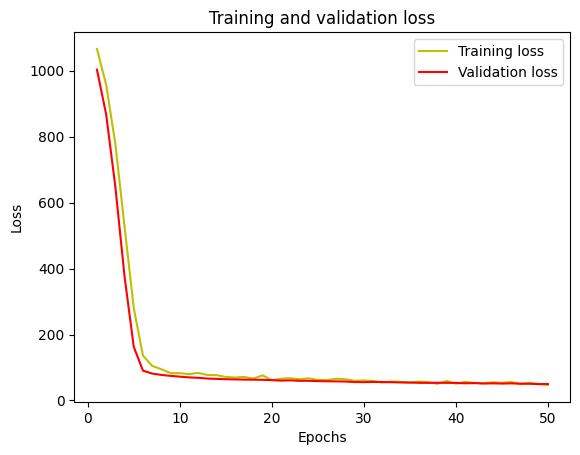

In [ ]:
# 학습 손실값 추출
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)

# Loss 그래프
# 학습 데이터와 검증 데이터의 손실값 변화를 확인한다.
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

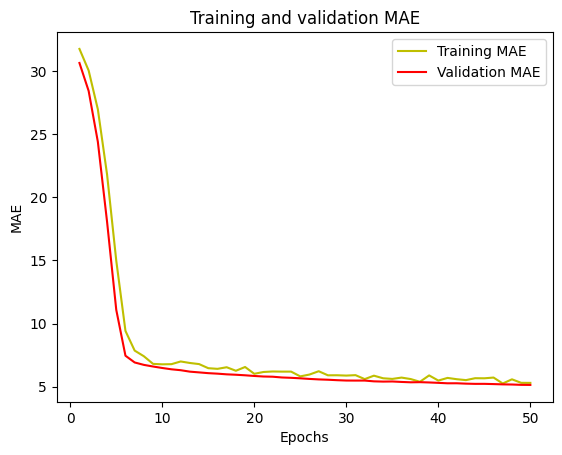

In [ ]:
# MAE 값 추출
mae = history.history['mae']
val_mae = history.history['val_mae']

# MAE 그래프
# 학습 데이터와 검증 데이터의 평균절대오차 변화를 확인한다.
plt.plot(epochs, mae, 'y', label='Training MAE')
plt.plot(epochs, val_mae, 'r', label='Validation MAE')
plt.title('Training and validation MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.show()

In [ ]:
# 회귀 성능 평가
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MSE: 50.27536092803952
MAE: 5.02671712157014
RMSE: 7.090512035674117
R2 Score: 0.15296770867656795
